## **SkolCoffee - Территориальный анализ / Наличие конкурентов**
**Структура:**


1.   Загрузка необходимых библиотек
2.   Поиск кофеен в радиусе 3км и вывод данных о 50 ближаших
3.   Территориальный анализ и построение интерактивной карты
4.   Выводы




# 1.

In [1]:

!pip install folium pandas requests

import requests
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import json
from math import radians, sin, cos, sqrt, atan2
from google.colab import files

## 2.

In [2]:
# Поиск кофеен в Сколково через Suggest API + Places API


import requests
import pandas as pd
import time

api_key = "83846033-3d9e-401c-8d1e-a5e1319b4339"

# ID Сколково через Suggest API
suggest_url = "https://catalog.api.2gis.com/3.0/suggests"
params = {
    'q': 'Сколково Москва',
    'key': api_key,
    'fields': 'items.point'
}

response = requests.get(suggest_url, params=params)
suggest_data = response.json()

# или координаты
lat, lon = 55.693394, 37.351932

# Поиск через Places API
all_results = []
keywords = ['кофейня', 'кафе', 'кофе', 'кофе с собой']

for kw in keywords:
    for page in range(1, 6):
        url = "https://catalog.api.2gis.com/3.0/items"
        params = {
            'q': kw,
            'point': f"{lon},{lat}",
            'radius': 3000,
            'page_size': 10,
            'page': page,
            'key': api_key,
            'sort': 'distance'
        }
        response = requests.get(url, params=params)
        data = response.json()

        if 'result' in data and 'items' in data['result']:
            for item in data['result']['items']:
                all_results.append({
                    'name': item.get('name'),
                    'address': item.get('address_name'),
                    'lat': item.get('point', {}).get('lat'),
                    'lon': item.get('point', {}).get('lon'),
                    'type': kw
                })
        time.sleep(0.5)

df_extended = pd.DataFrame(all_results)
df_extended = df_extended.drop_duplicates(subset=['name', 'address'])

print(f"Найдено заведений: {len(df_extended)}")
df_extended.head(50)

Найдено заведений: 135


,name,address,lat,lon,type
0,"ВкусВилл, кафе","улица Зворыкина, 1 к4",None,None,кофейня
1,"camper coffee, кофейня","улица Зворыкина, 2 к2",None,None,кофейня
2,"Camera Obscura, экспресс-кофейня","Большой бульвар, 42 ст1",None,None,кофейня
3,"Clever, кофейня","Большой бульвар, 42 ст1",None,None,кофейня
4,"Гусси кофе, кофейня","Большой бульвар, 42 ст1",None,None,кофейня
5,"Urban coffee, кофейня","Большой бульвар, 42 ст1",None,None,кофейня
6,"ВкусВилл, кафе","улица Зворыкина, 14 к2",None,None,кофейня
7,"One Price Coffee, кофейня","Большой бульвар, 40",None,None,кофейня
8,"Кофе твой друг, кофейня","Большой бульвар, 40",None,None,кофейня
9,"amore, кафе-джелатерия","Большой бульвар, 40",None,None,кофейня


## 3.

In [3]:
# ТЕРРИТОРИАЛЬНЫЙ АНАЛИЗ (ООП)


import pandas as pd
import folium
from math import radians, sin, cos, sqrt, atan2
from google.colab import files


# Класс точка на карте (для хранения координат и расчёта расстояний)
class Point:

    def __init__(self, lat: float, lon: float, name: str = ""):
        self.lat = lat
        self.lon = lon
        self.name = name

    def distance_to(self, other: 'Point') -> float:
        R = 6371
        lat1, lon1 = radians(self.lat), radians(self.lon)
        lat2, lon2 = radians(other.lat), radians(other.lon)
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        return R * c

    def __repr__(self):
        return f"Point({self.lat:.5f}, {self.lon:.5f}, '{self.name}')"


# Класс для хранения информации о кофейне
class Cafe:

    def __init__(self, name: str, address: str, lat: float, lon: float):
        self.name = name
        self.address = address
        self.location = Point(lat, lon, name)
        self.is_surf = 'Surf' in name or 'surf' in name

    def distance_to(self, point: Point) -> float:
        return self.location.distance_to(point)

    def to_dict(self) -> dict:      # Cловарь для DataFrame
        return {
            'name': self.name,
            'address': self.address,
            'lat': self.location.lat,
            'lon': self.location.lon,
            'is_surf': self.is_surf
        }

    def __repr__(self):
        return f"Cafe('{self.name}', '{self.address}')"


# Класс для анализа конкурентной среды
class TerritoryAnalyzer:

    def __init__(self, center: Point):
        self.center = center
        self.cafes = []
        self.df = None

    def add_cafe(self, cafe: Cafe):
        self.cafes.append(cafe)

    def add_cafes_from_list(self, cafes_data: list):
        for data in cafes_data:
            cafe = Cafe(
                name=data['name'],
                address=data['address'],
                lat=data['lat'],
                lon=data['lon']
            )
            self.cafes.append(cafe)

    def calculate_distances(self):      # Расстояние от всех кофеен до центра
        for cafe in self.cafes:
            cafe.distance_km = cafe.distance_to(self.center)

        self.cafes.sort(key=lambda x: x.distance_km)

    def to_dataframe(self) -> pd.DataFrame:
        data = [cafe.to_dict() for cafe in self.cafes]
        df = pd.DataFrame(data)
        df['distance_km'] = [getattr(c, 'distance_km', None) for c in self.cafes]
        df = df.sort_values('distance_km')
        self.df = df
        return df

    def get_statistics(self) -> dict:
        if self.df is None:
            self.to_dataframe()

        stats = {
            'total': len(self.cafes),
            '300m': len(self.df[self.df['distance_km'] <= 0.3]),
            '500m': len(self.df[self.df['distance_km'] <= 0.5]),
            '1000m': len(self.df[self.df['distance_km'] <= 1.0]),
            'surf_count': len(self.df[self.df['is_surf'] == True]),
            'closest': self.df.head(5)[['name', 'distance_km']].to_dict('records') if len(self.df) > 0 else []
        }
        return stats

    def create_map(self, filename: str = 'analysis_map.html'):    # Карта
        if self.df is None:
            self.to_dataframe()

        m = folium.Map(location=[self.center.lat, self.center.lon], zoom_start=15)

        # Круги 300м, 500м и 1000м
        folium.Circle(radius=300, location=[self.center.lat, self.center.lon],
                      color='red', weight=2, fill=True, fill_opacity=0.15,
                      popup='300 м').add_to(m)
        folium.Circle(radius=500, location=[self.center.lat, self.center.lon],
                      color='blue', weight=2, fill=True, fill_opacity=0.1,
                      popup='500 м').add_to(m)
        folium.Circle(radius=1000, location=[self.center.lat, self.center.lon],
                      color='green', weight=2, fill=True, fill_opacity=0.1,
                      popup='1000 м').add_to(m)

        # Предположительная точка для нашей кофени
        folium.Marker(location=[self.center.lat, self.center.lon],
                      popup="<b> Scolcoffe </b>",
                      icon=folium.Icon(color='green', icon='star', prefix='fa')).add_to(m)

        # Конкуренты
        for _, row in self.df.iterrows():
            color = 'pink' if row['is_surf'] else 'red'
            icon = 'surfing' if row['is_surf'] else 'coffee'
            folium.Marker(location=[row['lat'], row['lon']],
                          popup=f"<b>{row['name']}</b><br>{row['address']}<br> {row['distance_km']:.2f} км",
                          icon=folium.Icon(color=color, icon=icon, prefix='fa')).add_to(m)

        # МЦД-1
        folium.Marker(location=[55.700297, 37.342827],
                      popup="<b> МЦД-1 Станция Сколково</b>",
                      icon=folium.Icon(color='blue', icon='train', prefix='fa')).add_to(m)

        m.save(filename)
        files.download(filename)
        return m

    def print_summary(self):
        stats = self.get_statistics()

        print("ИТОГИ ТЕРРИТОРИАЛЬНОГО АНАЛИЗА")

        print(f"\n Наша точка: {self.center.lat:.5f}, {self.center.lon:.5f}")
        print(f"\n В радиусе 300 м: {stats['300m']} кофеен")
        print(f" В радиусе 500 м: {stats['500m']} кофеен")
        print(f" В радиусе 1 км: {stats['1000m']} кофеен")
        print(f" Сёрф-кофеен: {stats['surf_count']}")

        if stats['closest']:
            print("\n 5 ближайших конкурентов:")
            for c in stats['closest']:
                print(f"    {c['name']} — {c['distance_km']:.2f} км")


        if stats['500m'] == 0:
            verdict = "КОНКУРЕНТОВ НЕТ"
        elif stats['500m'] <= 10:
            verdict = "КОНКУРЕНЦИЯ НИЗКАЯ"
        else:
            verdict = "СРЕДНЯЯ КОНКУРЕНЦИЯ"

        print(f"\n{verdict}")




# СОБИРАЕМ ДАННЫЕ И ЗАПУСКАЕМ АНАЛИЗ

if __name__ == "__main__":

    # 1. Создаём точку нашей кофейни
    our_cafe = Point(lat=55.693394, lon=37.351932, name="Наша кофейня")

    # 2. Создаём анализатор
    analyzer = TerritoryAnalyzer(center=our_cafe)

    # 3. Данные о ближайших конкурентах (из геокодинга)
    competitors_data = [
        {"name": "ВкусВилл, кафе", "address": "улица Зворыкина, 1 к4", "lat": 55.693561, "lon": 37.351725},
    {"name": "camper coffee, кофейня", "address": "улица Зворыкина, 2 к2", "lat": 55.69287, "lon": 37.35161},
    {"name": "ВкусВилл, кафе", "address": "улица Зворыкина, 14 к2", "lat": 55.68969, "lon": 37.35164},
    {"name": "Кофе-он мой?, кофейня", "address": "улица Нобеля, 5", "lat": 55.68444, "lon": 37.34200},
    {"name": "Груша х Рэш, кофейня", "address": "улица Нобеля, 3", "lat": 55.68471, "lon": 37.34090},
    {"name": "Кофейня", "address": "улица Нобеля, 1", "lat": 55.68492, "lon": 37.33979},
    {"name": "Camera Obscura, экспресс-кофейня", "address": "Большой бульвар, 42 ст1", "lat": 55.692318, "lon": 37.347485},
    {"name": "Clever, кофейня", "address": "Большой бульвар, 42 ст1", "lat": 55.692318, "lon": 37.347485},
    {"name": "Гусси кофе, кофейня", "address": "Большой бульвар, 42 ст1", "lat": 55.692318, "lon": 37.347485},
    {"name": "Urban coffee, кофейня", "address": "Большой бульвар, 42 ст1", "lat": 55.692318, "lon": 37.347485},
    {"name": "One Price Coffee, кофейня", "address": "Большой бульвар, 40", "lat": 55.695261, "lon": 37.347135},
    {"name": "Кофе твой друг, кофейня", "address": "Большой бульвар, 40", "lat": 55.695261, "lon": 37.347135},
    {"name": "amore, кафе-джелатерия", "address": "Большой бульвар, 40", "lat": 55.695261, "lon": 37.347135},
    {"name": "Буста, кофейня", "address": "Большой бульвар, 40", "lat": 55.695261, "lon": 37.347135},
    {"name": "Кофейня", "address": "Большой бульвар, 30 ст1", "lat": 55.698538, "lon": 37.359576},
    {"name": "57 Кофе", "address": "Большой бульвар, 30 ст1", "lat": 55.698538, "lon": 37.359576},
    {"name": "Althaus, кофейня", "address": "Большой бульвар, 44", "lat": 55.685797, "lon": 37.351482},
    {"name": "Татнефть, точка кофе", "address": "Большой бульвар, 62", "lat": 55.683711, "lon": 37.337756},
    {"name": "Кафетерий", "address": "Большой бульвар, 67", "lat": 55.681468, "lon": 37.341376},
    {"name": "Specialty, экспресс-кофейня", "address": "бульвар Эйнштейна, 1", "lat": 55.701125, "lon": 37.358489},
    {"name": "Снегири, кофейня", "address": "бульвар Эйнштейна, 2", "lat": 55.700775, "lon": 37.360079},
    {"name": "Здрасте, кофейня", "address": "бульвар Эйнштейна, к5", "lat": 55.701749, "lon": 37.357465},
    {"name": "ВкусВилл, кафе", "address": "бульвар Эйнштейна, 2", "lat": 55.700775, "lon": 37.360079},
    {"name": "Do.Bro Кофе", "address": "бульвар Эйнштейна, 3", "lat": 55.701333, "lon": 37.361705},
    {"name": "Lavendiya coffee&bakery, кофейня", "address": "бульвар Эйнштейна, 4", "lat": 55.702084, "lon": 37.364697},
    {"name": "Surf coffee x Startup, кофейня", "address": "Западная улица, 181", "lat": 55.699497, "lon": 37.343649},
    {"name": "По Фрейду, экспресс-кофейня", "address": "Западная улица, ст180", "lat": 55.699000, "lon": 37.343029},
    {"name": "Кантата, магазин кофе и сладостей", "address": "Западная улица, ст180", "lat": 55.70050, "lon": 37.36500},
    {"name": "Азбука Вкуса, кофейня", "address": "Западная улица, 12", "lat": 55.709003, "lon": 37.361553},
    {"name": "Магазин табачной продукции", "address": "Западная улица, ст4", "lat": 55.70100, "lon": 37.36700},
    {"name": "Coffee, кофейня", "address": "Трёхгорная улица, 6", "lat": 55.696976, "lon": 37.336705},
    {"name": "Specialty, экспресс-кофейня", "address": "Трёхгорная улица, 4", "lat": 55.695961, "lon": 37.335681},
    {"name": "Здрасте, кофейня", "address": "улица Сколковская, 1Б", "lat": 55.695129, "lon": 37.324524},
    {"name": "Луви-Луви, кафе", "address": "улица Сколковская, 1г", "lat": 55.694662, "lon": 37.322287},
    {"name": "Oxofoxo, кофейня", "address": "улица Сколковская, 3а", "lat": 55.696387, "lon": 37.322961},
    {"name": "Proper coffee, кофейня", "address": "улица Сколковская, 5а", "lat": 55.697726, "lon": 37.321721},
    {"name": "F42, кофейня", "address": "улица Сколковская, 5Б", "lat": 55.698624, "lon": 37.320715},
    {"name": "Табак&вейп, магазин табачной продукции", "address": "улица Чистяковой, 1", "lat": 55.695317, "lon": 37.333274},
    {"name": "Бодрый, кофейня", "address": "улица Чистяковой, 67", "lat": 55.700791, "lon": 37.320428},
    {"name": "Кофейня", "address": "улица Чистяковой, 52", "lat": 55.702886, "lon": 37.319745},
    {"name": "Lightning, кофейня", "address": "Кутузовская улица, 2", "lat": 55.702328, "lon": 37.326321},
    {"name": "Бодрый, кофейня", "address": "Кутузовская улица, 4", "lat": 55.703814, "lon": 37.327336},
    {"name": "Няшки&Вкусняшки, магазин", "address": "Кутузовская улица, 25", "lat": 55.706284, "lon": 37.325270},
    {"name": "Family Home, кафетерий", "address": "Можайское шоссе, 1", "lat": 55.71200, "lon": 37.36000},
    {"name": "Экспресс-кофейня", "address": "Можайское шоссе, 51", "lat": 55.706705, "lon": 37.380246},
    {"name": "Coffee, кофейня", "address": "улица Сикорского, 11", "lat": 55.681458, "lon": 37.332770},
    {"name": "Campus coffee, экспресс-кофейня", "address": "Новая улица, 100", "lat": 55.69547, "lon": 37.39059},
    {"name": "Кофепорт, кофейня", "address": "Новая улица, 100", "lat": 55.69547, "lon": 37.39059},
    {"name": "Surf Coffee x Stratos", "address": "улица Николы Теслы, 1 ст1", "lat": 55.695225, "lon": 37.345320},
    {"name": "Slava Bloom", "address": "Родниковая улица, 22а", "lat": 55.698406, "lon": 37.316664},
    ]

    # 4. Добавляем конкурентов в анализатор
    analyzer.add_cafes_from_list(competitors_data)

    # 5. Рассчитываем расстояния
    analyzer.calculate_distances()

    # 6. Выводим статистику
    analyzer.print_summary()

    # 7. Создаём карту
    analyzer.create_map('skolkovo_oop_map.html')

    # 8. Сохраняем DataFrame
    df = analyzer.to_dataframe()
    df.to_csv('skolkovo_oop_analysis.csv', index=False)
    files.download('skolkovo_oop_analysis.csv')

    print("\n Файлы скачаны: карта и CSV с результатами")

ИТОГИ ТЕРРИТОРИАЛЬНОГО АНАЛИЗА

 Наша точка: 55.69339, 37.35193

 В радиусе 300 м: 2 кофеен
 В радиусе 500 м: 12 кофеен
 В радиусе 1 км: 21 кофеен
 Сёрф-кофеен: 2

 5 ближайших конкурентов:
    ВкусВилл, кафе — 0.02 км
    camper coffee, кофейня — 0.06 км
    Camera Obscura, экспресс-кофейня — 0.30 км
    Clever, кофейня — 0.30 км
    Гусси кофе, кофейня — 0.30 км

СРЕДНЯЯ КОНКУРЕНЦИЯ


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Файлы скачаны: карта и CSV с результатами


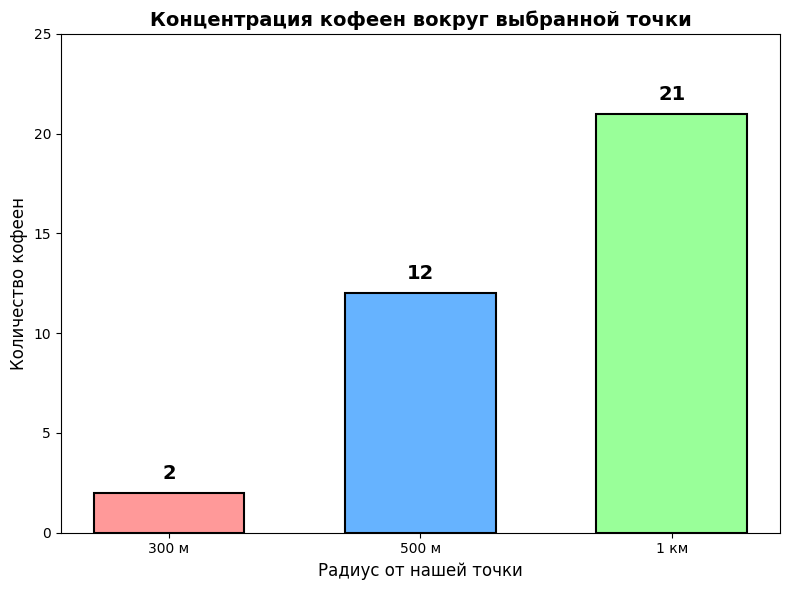

In [6]:
# ГИСТОГРАММА: КОЛИЧЕСТВО КОФЕЕН ПО РАДИУСАМ

import matplotlib.pyplot as plt

radii = ['300 м', '500 м', '1 км']
counts = [2, 12, 21]

colors = ['#ff9999', '#66b3ff', '#99ff99']

# Создаём график
plt.figure(figsize=(8, 6))

bars = plt.bar(radii, counts, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Подписи
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.ylabel('Количество кофеен', fontsize=12)
plt.xlabel('Радиус от нашей точки', fontsize=12)
plt.title('Концентрация кофеен вокруг выбранной точки', fontsize=14, fontweight='bold')
plt.ylim(0, 25)


plt.tight_layout()
plt.show()


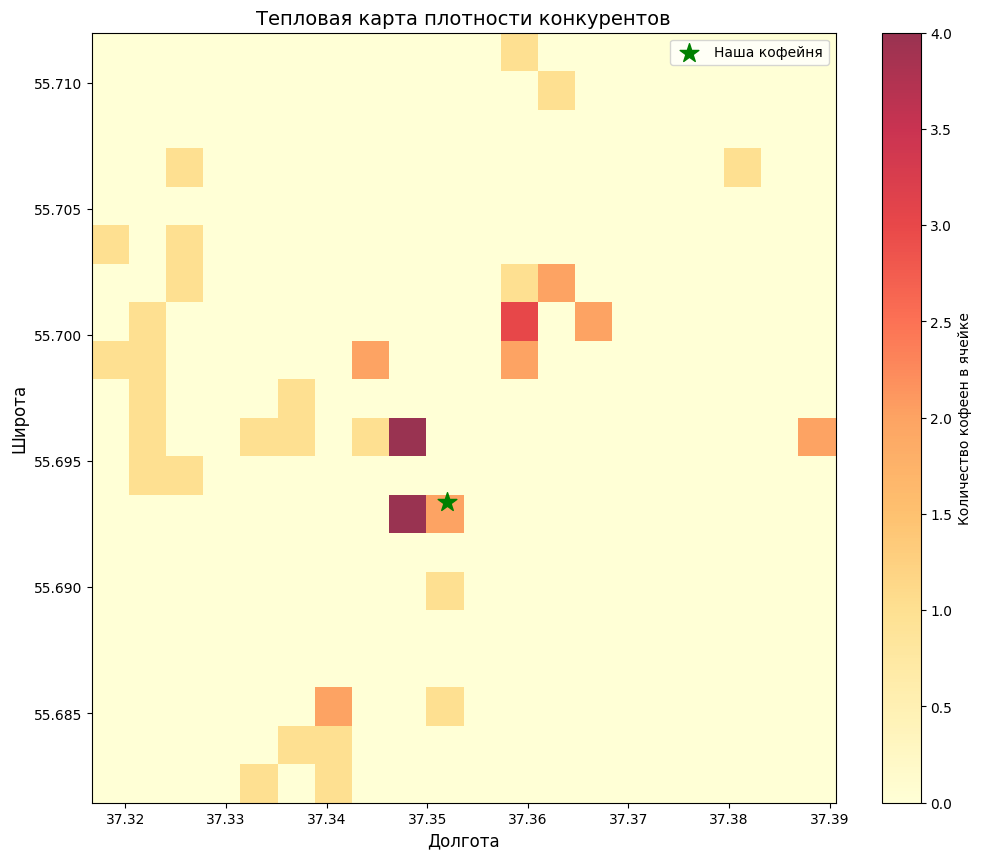

In [9]:
plt.figure(figsize=(12, 10))
plt.hist2d(df['lon'], df['lat'], bins=20, cmap='YlOrRd', alpha=0.8)
plt.colorbar(label='Количество кофеен в ячейке')
plt.scatter([our_cafe.lon], [our_cafe.lat],
            color='green', s=200, marker='*', label='Наша кофейня')
plt.xlabel('Долгота', fontsize=12)
plt.ylabel('Широта', fontsize=12)
plt.title('Тепловая карта плотности конкурентов', fontsize=14)
plt.legend()
plt.show()

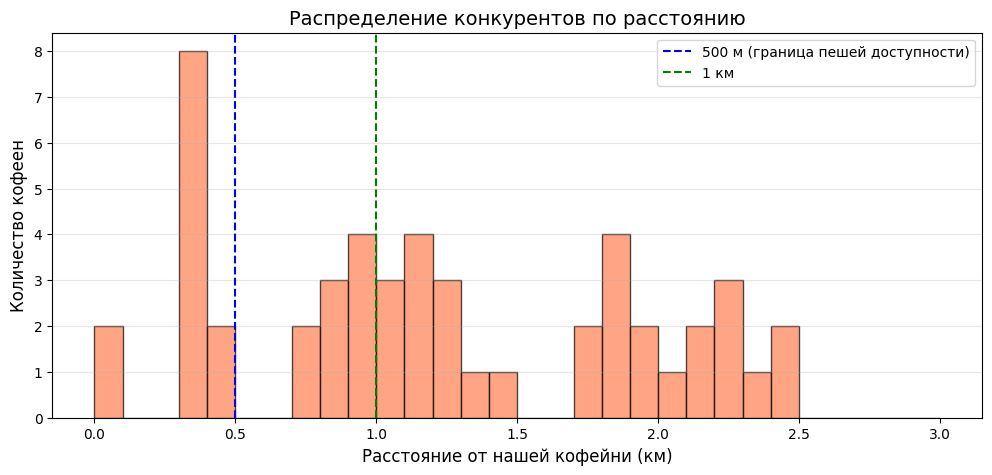

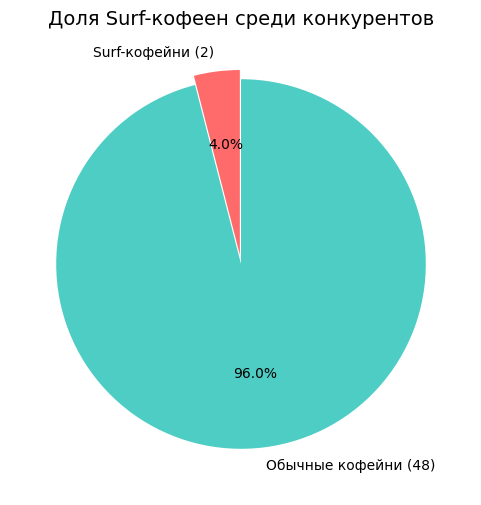

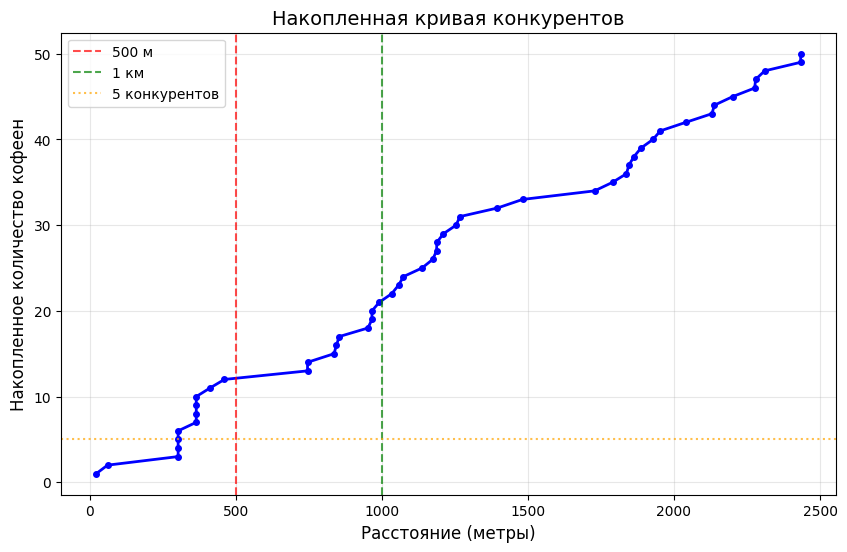

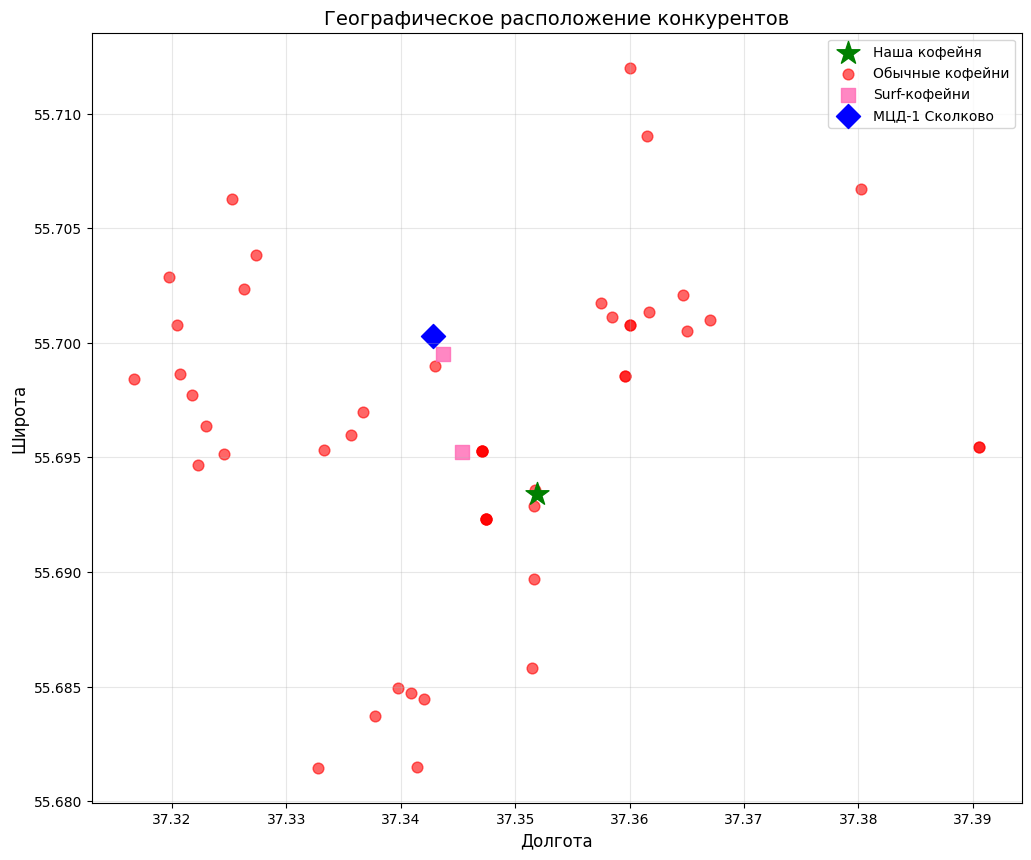

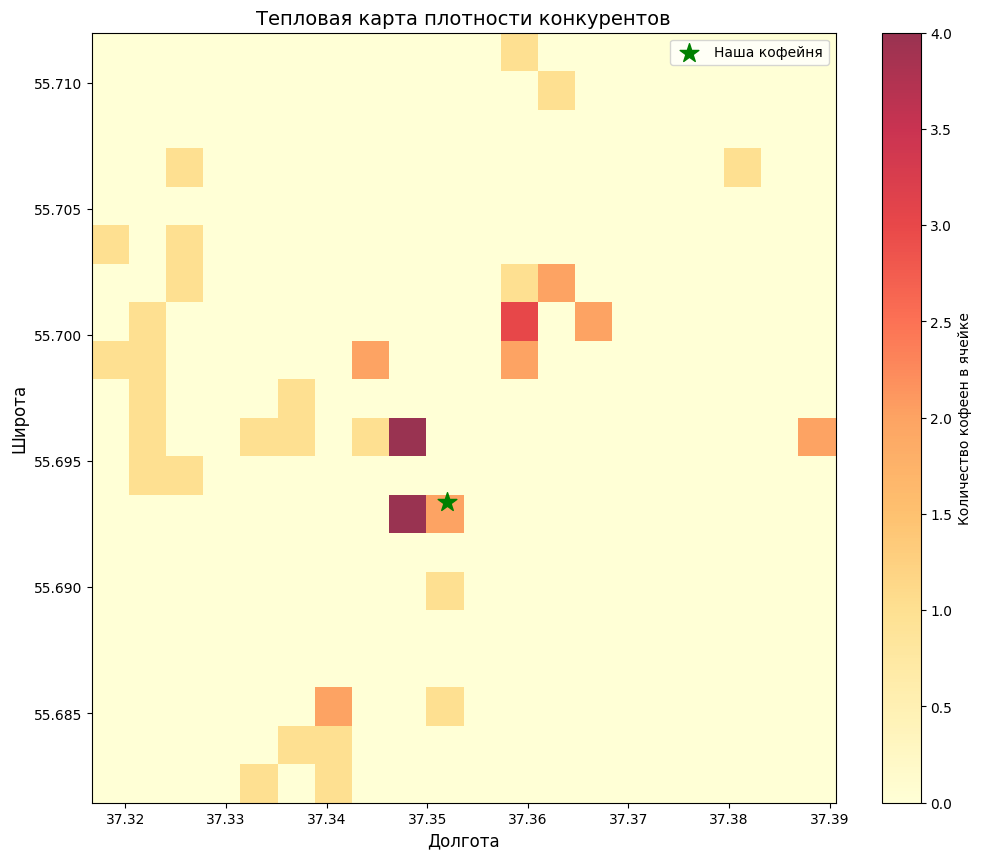

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#ГИСТОГРАММА
bins = np.arange(0, 3.1, 0.1)
distances = df['distance_km'].values

plt.figure(figsize=(12, 5))
plt.hist(distances, bins=bins, edgecolor='black', color='coral', alpha=0.7)
plt.xlabel('Расстояние от нашей кофейни (км)', fontsize=12)
plt.ylabel('Количество кофеен', fontsize=12)
plt.title('Распределение конкурентов по расстоянию', fontsize=14)
plt.axvline(x=0.5, color='blue', linestyle='--', label='500 м (граница пешей доступности)')
plt.axvline(x=1.0, color='green', linestyle='--', label='1 км')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# КРУГОВАЯ ДИАГРАММА
surf_count = len(df[df['is_surf'] == True])
regular_count = len(df[df['is_surf'] == False])

plt.figure(figsize=(6, 6))
plt.pie([surf_count, regular_count],
        labels=[f'Surf-кофейни ({surf_count})', f'Обычные кофейни ({regular_count})'],
        colors=['#FF6B6B', '#4ECDC4'],
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0))
plt.title('Доля Surf-кофеен среди конкурентов', fontsize=14)
plt.show()

#НАКОПЛЕННАЯ КРИВАЯ
distances_sorted = np.sort(df['distance_km'].values)
cumulative = np.arange(1, len(distances_sorted) + 1)

plt.figure(figsize=(10, 6))
plt.plot(distances_sorted * 1000, cumulative, 'b-', linewidth=2, marker='o', markersize=4)
plt.xlabel('Расстояние (метры)', fontsize=12)
plt.ylabel('Накопленное количество кофеен', fontsize=12)
plt.title('Накопленная кривая конкурентов', fontsize=14)
plt.axvline(x=500, color='red', linestyle='--', label='500 м', alpha=0.7)
plt.axvline(x=1000, color='green', linestyle='--', label='1 км', alpha=0.7)
plt.axhline(y=5, color='orange', linestyle=':', label='5 конкурентов', alpha=0.7)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#ТОЧЕЧНАЯ ДИАГРАММА
plt.figure(figsize=(12, 10))

# Наша точка
our_cafe = Point(lat=55.693394, lon=37.351932, name="Наша кофейня")
plt.scatter([our_cafe.lon], [our_cafe.lat],
            color='green', s=300, marker='*', zorder=5, label='Наша кофейня')

# Обычные кофейни
regular = df[df['is_surf'] == False]
plt.scatter(regular['lon'], regular['lat'],
            color='red', s=60, alpha=0.6, label='Обычные кофейни')

# Surf-кофейни
surf = df[df['is_surf'] == True]
plt.scatter(surf['lon'], surf['lat'],
            color='hotpink', s=100, marker='s', alpha=0.8, label='Surf-кофейни')

# МЦД
plt.scatter([37.342827], [55.700297],
            color='blue', s=150, marker='D', label='МЦД-1 Сколково')

plt.xlabel('Долгота', fontsize=12)
plt.ylabel('Широта', fontsize=12)
plt.title('Географическое расположение конкурентов', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ТЕПЛОВАЯ КАРТА
plt.figure(figsize=(12, 10))
plt.hist2d(df['lon'], df['lat'], bins=20, cmap='YlOrRd', alpha=0.8)
plt.colorbar(label='Количество кофеен в ячейке')
plt.scatter([our_cafe.lon], [our_cafe.lat],
            color='green', s=200, marker='*', label='Наша кофейня')
plt.xlabel('Долгота', fontsize=12)
plt.ylabel('Широта', fontsize=12)
plt.title('Тепловая карта плотности конкурентов', fontsize=14)
plt.legend()
plt.show()



## 4.

# Выводы:
1. Конкурентная среда:

В радиусе 500 м от предполагаемой точки открытия находится 12 кофеен

В радиусе 1 км — 21 кофеен

Это говорит о средней конкуренции в окрестности выбранной точки.

2. Аналоги:

В Сколково уже работают 2 сёрф-кофейни (Surf Coffee x Stratos и Surf coffee x Startup)

Они находятся на расстоянии 0.4–0.9 км от нашей точки, что подтверждает востребованность формата, но оставляет нам пространство для уникального предложения.

3. Транспортная доступность

Станция МЦД-1 «Сколково» находится в пешей доступности (менее 1000 м), также присутствуют автобусные маршруты. В результате потенциальный трафик ожидается высокий.

4. Итог

Транспортная доступность, средняя конкуренция, место перспективное, рынок не перенасыщен, а формат востребован. Есть смысл открыть заведение с уникальным предложением (атмосфера и авторские напитки), чтобы отличаться от существующих кофеен.

